## Imports & DB connection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

DB_CONFIG = {
    "user": "postgres",
    "password": "Dhrumil2006",
    "host": "localhost",
    "port": "5432",
    "dbname": "reviewshield",
}
conn_string = f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
engine = create_engine(conn_string)

## Load joined data (features + labels)

In [2]:
query = """
SELECT r.review_id, r.label, r.rating,
       f.punctuation_freq, f.vocab_diversity, f.readability_score,
       f.avg_sentence_length, f.sentiment_score, f.rating_sentiment_gap
FROM raw_reviews r
JOIN engineered_features f ON r.review_id = f.review_id
"""
df = pd.read_sql(query, engine)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 40412 rows


,review_id,label,rating,punctuation_freq,vocab_diversity,readability_score,avg_sentence_length,sentiment_score,rating_sentiment_gap
0,1,CG,5.0,6.8493,0.8462,73.8450,3.25,0.9592,0.0408
1,2,CG,5.0,3.7975,0.9412,87.6775,8.50,0.8910,0.1090
2,3,CG,5.0,2.9851,0.8571,103.0443,7.00,0.7906,0.2094
3,4,CG,1.0,2.5000,0.9412,80.0976,8.50,0.7463,1.7463
4,5,CG,5.0,2.3529,0.8889,99.0000,6.00,0.7397,0.2603


## Grouped summary stats by label

In [3]:
df.groupby("label")[[
    "punctuation_freq", "vocab_diversity", "readability_score",
    "avg_sentence_length", "sentiment_score", "rating_sentiment_gap"
]].mean().round(4)

,punctuation_freq,vocab_diversity,readability_score,avg_sentence_length,sentiment_score,rating_sentiment_gap
label,,,,,,
CG,2.9018,0.7209,86.6667,10.7279,0.6416,0.4705
OR,3.0140,0.8030,77.1878,13.7418,0.5925,0.3924


## Boxplots comparing CG vs OR per feature

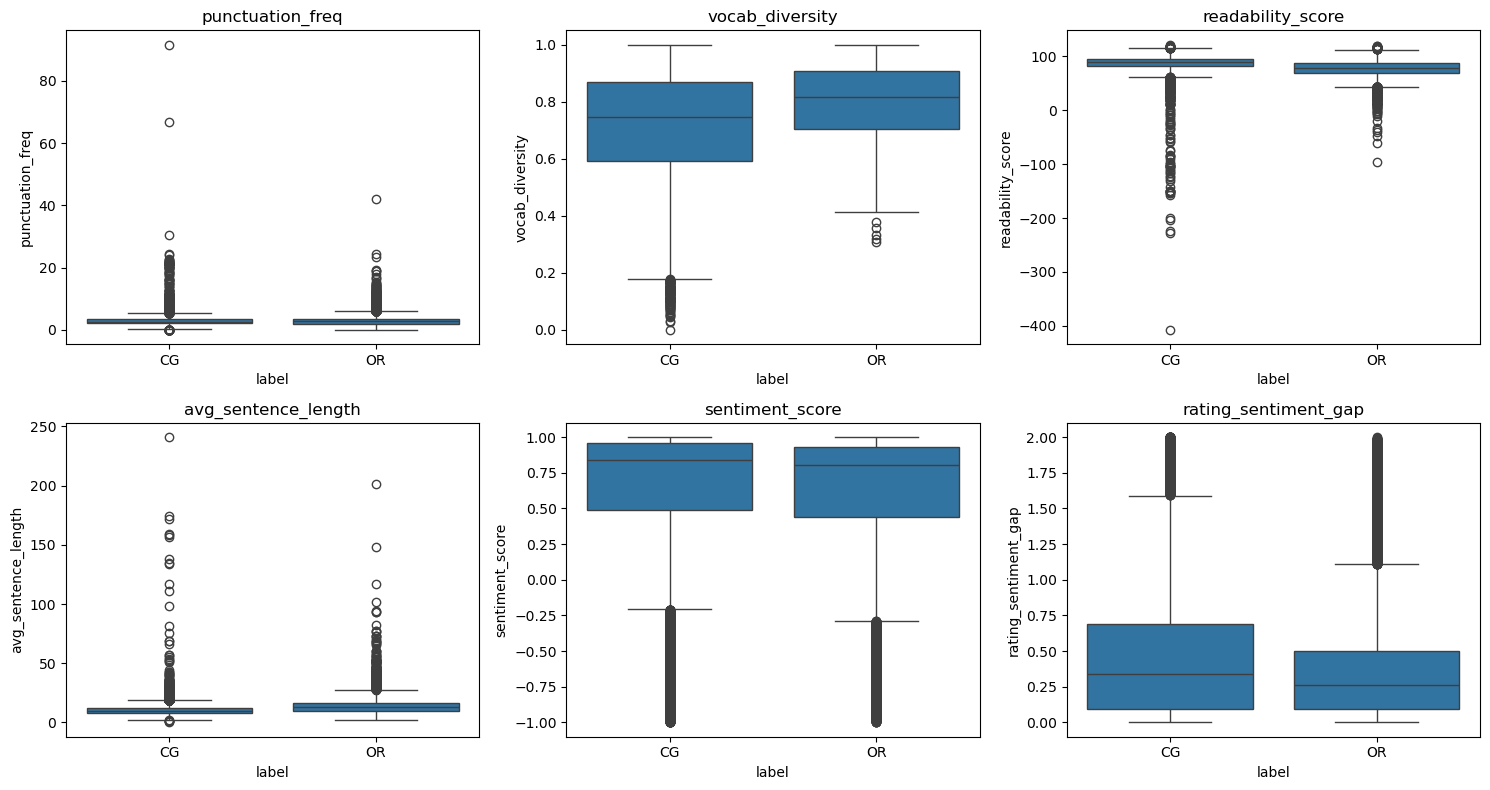

In [4]:
features = ["punctuation_freq", "vocab_diversity", "readability_score",
            "avg_sentence_length", "sentiment_score", "rating_sentiment_gap"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="label", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## Rating-sentiment gap distribution (core hypothesis)

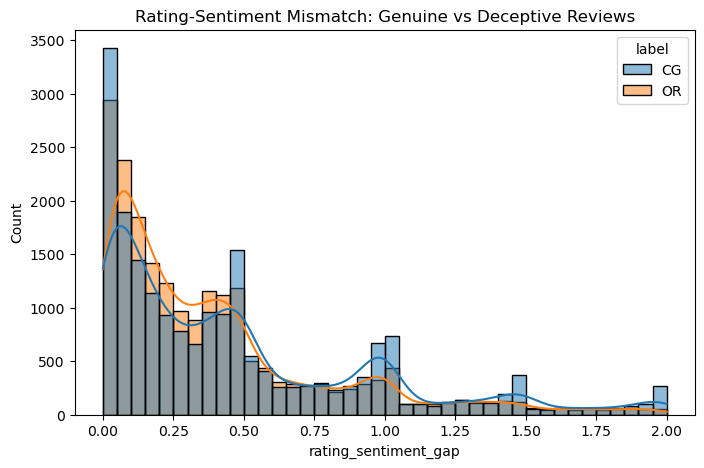

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="rating_sentiment_gap", hue="label", kde=True, bins=40)
plt.title("Rating-Sentiment Mismatch: Genuine vs Deceptive Reviews")
plt.show()

## Correlation heatmap

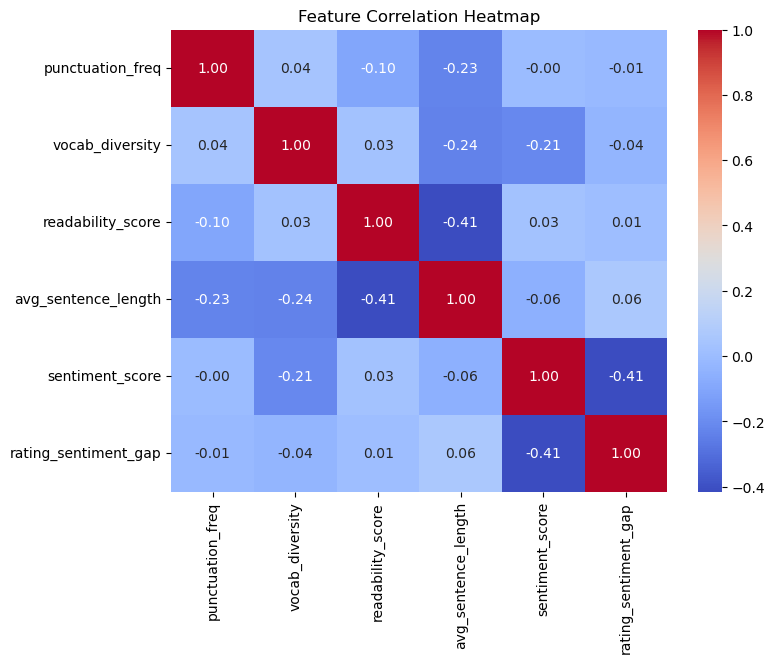

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()